# Lab 10: Attention, Transfer Learning and Text for Forecasting

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/solutions/lab10_attention_and_forecasting_solutions.ipynb)

This lab accompanies Lecture 10 and closes the course. By the end of the session you should be able to:

1. Implement scaled dot-product attention in numpy and read an attention matrix.
2. Extend it to multiple heads and explain what positional encoding repairs.
3. Use a pretrained language model for a task it was never trained on, and describe what transfer learning is transferring.
4. Build monthly features from a text corpus and test whether they improve a macroeconomic forecast.
5. State what the evidence in this course supports, and what it does not.

Parts 1, 2, 4 and 5 run anywhere in numpy and scikit-learn. Part 3 uses a pretrained transformer and is switched off by default; turn it on when you have a Colab session and a few spare minutes.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:30 | Part 1. Attention from scratch |
| 0:30 - 0:50 | Part 2. Multiple heads and position |
| 0:50 - 1:10 | Part 3. Transfer learning |
| 1:10 - 1:45 | Part 4. Does text improve a macroeconomic forecast? |
| 1:45 - 2:00 | Part 5. Course synthesis |

## Setup

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"

if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

# Part 3 downloads a pretrained model of a few hundred megabytes. Set this to
# True in a Colab session to run it.
RUN_TRANSFORMERS = False

## Part 1. Attention from scratch

Every representation in Lab 9 was static: the vector for "tightening" was the same regardless of what surrounded it. Attention makes a representation depend on context. Each token proposes a query, every token advertises a key, and the output for a token is a weighted average of the value vectors, weighted by how well its query matches each key:

$$ \text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\!\left( \frac{\mathbf{Q}\mathbf{K}'}{\sqrt{d_k}} \right)\mathbf{V} . $$

The scaling by $\sqrt{d_k}$ stops the dot products growing with dimension and pushing the softmax into saturation, where its gradients vanish.

In [2]:
def softmax(scores, axis=-1):
    """Numerically stable softmax."""
    shifted = scores - scores.max(axis=axis, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=axis, keepdims=True)


def attention(Q, K, V, mask=None):
    """Scaled dot-product attention; returns the output and the attention weights."""
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores)
    return weights @ V, weights

To see attention doing something meaningful we need embeddings with real structure. We rebuild the co-occurrence embeddings from Lab 9, then feed a short sequence of policy vocabulary through a single attention layer with random projections.

In [3]:
meetings = e5.load_fomc_meetings()
tokens_by_meeting = [e5.tokenise(doc) for doc in meetings["text"]]

from collections import Counter

counts = Counter(t for tokens in tokens_by_meeting for t in tokens)
vocabulary = [w for w, _ in counts.most_common(400)]
index = {w: i for i, w in enumerate(vocabulary)}

C = np.zeros((len(vocabulary), len(vocabulary)))
for tokens in tokens_by_meeting:
    ids = [index[t] for t in tokens if t in index]
    for position, centre in enumerate(ids):
        for other in ids[max(0, position - 5):position] + ids[position + 1:position + 6]:
            C[centre, other] += 1.0

total = C.sum()
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((C / total) / np.outer(C.sum(axis=1) / total, C.sum(axis=0) / total))
ppmi = np.nan_to_num(np.maximum(pmi, 0.0), nan=0.0, posinf=0.0, neginf=0.0)

U_emb, d_emb, _ = np.linalg.svd(ppmi, full_matrices=False)
d_model = 32
embeddings = U_emb[:, :d_model] * d_emb[:d_model]
embeddings /= (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)

print(f"embedding matrix: {embeddings.shape[0]} words in {d_model} dimensions")

embedding matrix: 400 words in 32 dimensions


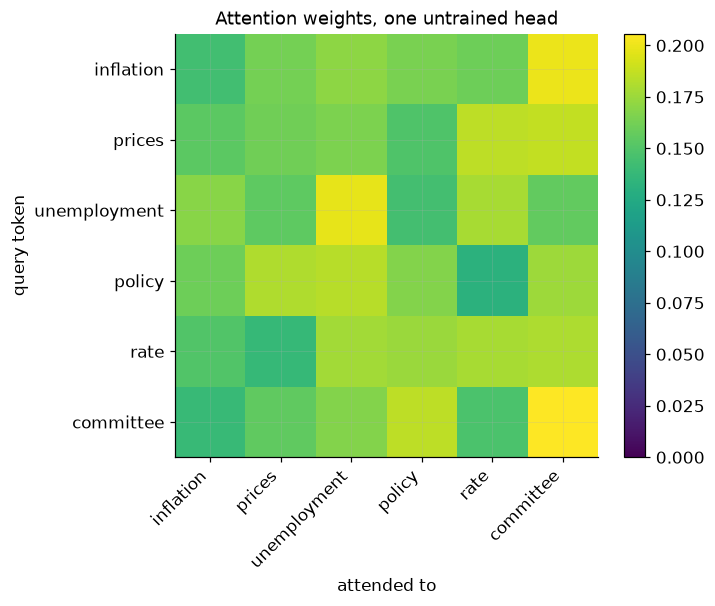

each row sums to one: True


In [4]:
sequence = [w for w in ["inflation", "prices", "unemployment", "policy", "rate", "committee"]
            if w in index]
E = embeddings[[index[w] for w in sequence]]

W_q = rng.normal(scale=0.4, size=(d_model, 16))
W_k = rng.normal(scale=0.4, size=(d_model, 16))
W_v = rng.normal(scale=0.4, size=(d_model, 16))

output, weights = attention(E @ W_q, E @ W_k, E @ W_v)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights, cmap="viridis", vmin=0)
ax.set_xticks(range(len(sequence)), sequence, rotation=45, ha="right")
ax.set_yticks(range(len(sequence)), sequence)
ax.set_xlabel("attended to")
ax.set_ylabel("query token")
ax.set_title("Attention weights, one untrained head")
fig.colorbar(im, fraction=0.046)
plt.show()

print(f"each row sums to one: {np.allclose(weights.sum(axis=1), 1.0)}")

The projections here are random, so the pattern reflects the geometry of the embeddings rather than anything learned. In a trained model $\mathbf{W}_q$, $\mathbf{W}_k$ and $\mathbf{W}_v$ are estimated, and different heads specialise.

### Exercise 1

The temperature of the softmax controls how sharply attention concentrates.

1. Modify `attention` to accept a temperature parameter dividing the scores.
2. Compute the weights at temperatures 0.1, 1 and 10 for the sequence above.
3. Plot the three attention matrices side by side, and report the average entropy of the rows in each case.

What does attention become in the limit of very low temperature, and what in the limit of very high?

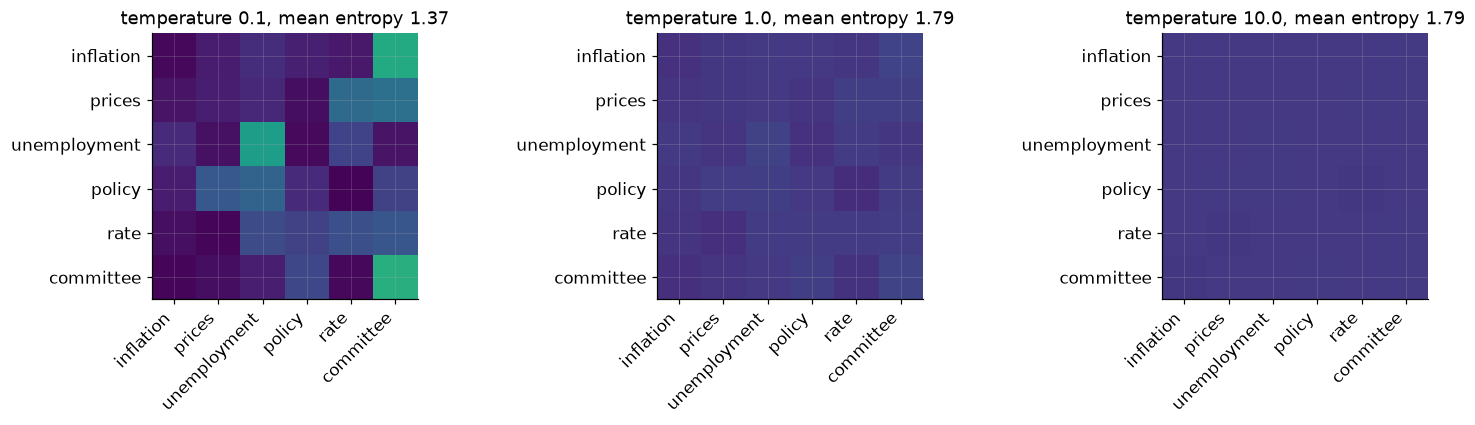

maximum possible entropy for 6 tokens: 1.79


In [5]:
def attention_with_temperature(Q, K, V, temperature=1.0):
    """Scaled dot-product attention with an explicit softmax temperature."""
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / (np.sqrt(d_k) * temperature)
    weights = softmax(scores)
    return weights @ V, weights


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, temp in zip(axes, [0.1, 1.0, 10.0]):
    _, w = attention_with_temperature(E @ W_q, E @ W_k, E @ W_v, temperature=temp)
    ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(sequence)), sequence, rotation=45, ha="right")
    ax.set_yticks(range(len(sequence)), sequence)
    entropy = -np.sum(w * np.log(w + 1e-12), axis=1).mean()
    ax.set_title(f"temperature {temp}, mean entropy {entropy:.2f}")
fig.tight_layout()
plt.show()

print(f"maximum possible entropy for {len(sequence)} tokens: {np.log(len(sequence)):.2f}")

## Part 2. Multiple heads and position

One attention head produces one weighted average. Multiple heads run in parallel with separate projections, and their outputs are concatenated, so different heads can capture different relations.

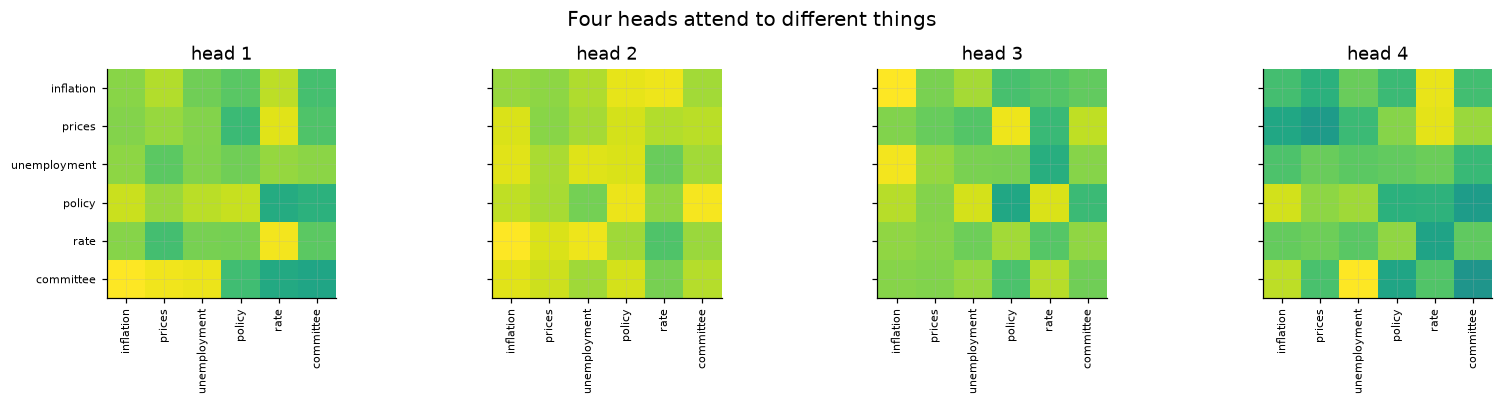

output dimension after concatenation: (6, 32)


In [6]:
def multi_head_attention(E, n_heads=4, d_head=8, generator=None):
    """Concatenated output of several independently projected attention heads."""
    generator = generator or np.random.default_rng(0)
    outputs, all_weights = [], []
    for _ in range(n_heads):
        Wq = generator.normal(scale=0.4, size=(E.shape[1], d_head))
        Wk = generator.normal(scale=0.4, size=(E.shape[1], d_head))
        Wv = generator.normal(scale=0.4, size=(E.shape[1], d_head))
        out, w = attention(E @ Wq, E @ Wk, E @ Wv)
        outputs.append(out)
        all_weights.append(w)
    return np.concatenate(outputs, axis=-1), np.array(all_weights)


combined, head_weights = multi_head_attention(E, n_heads=4, generator=rng)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for k, ax in enumerate(axes):
    ax.imshow(head_weights[k], cmap="viridis", vmin=0)
    ax.set_xticks(range(len(sequence)), sequence, rotation=90, fontsize=7)
    ax.set_yticks(range(len(sequence)), sequence if k == 0 else [""] * len(sequence), fontsize=7)
    ax.set_title(f"head {k + 1}")
fig.suptitle("Four heads attend to different things")
fig.tight_layout()
plt.show()

print(f"output dimension after concatenation: {combined.shape}")

### Position

Attention is permutation equivariant: shuffle the input tokens and the outputs shuffle with them, unchanged. For language that is a defect, because word order carries meaning. Transformers repair it by adding a positional encoding to the embeddings before the first layer,

$$ PE_{(t, 2i)} = \sin\left(\frac{t}{10000^{2i/d}}\right), \qquad PE_{(t, 2i+1)} = \cos\left(\frac{t}{10000^{2i/d}}\right). $$

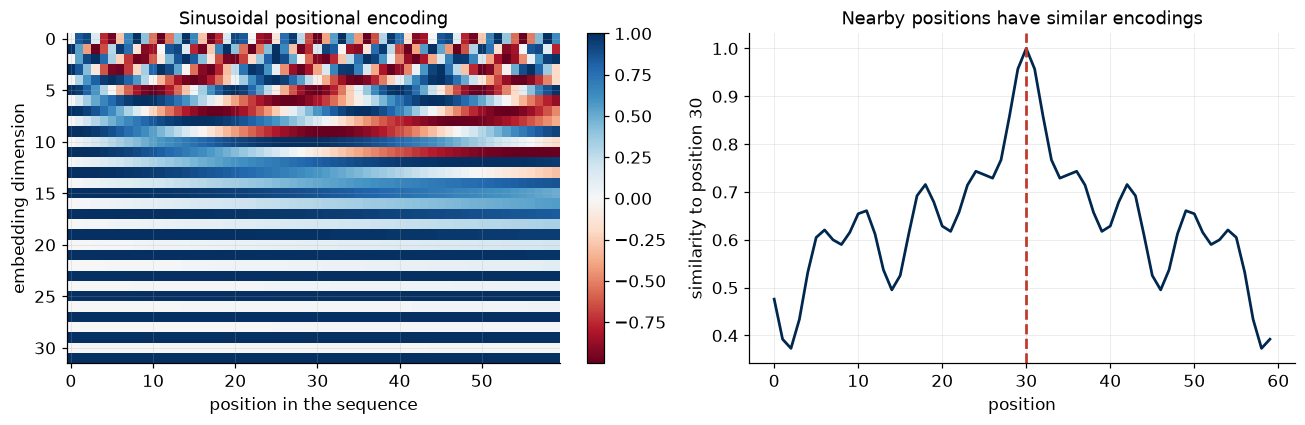

In [7]:
def positional_encoding(length, d_model):
    """Sinusoidal positional encodings."""
    position = np.arange(length)[:, None]
    dimension = np.arange(d_model)[None, :]
    angle = position / np.power(10000.0, (2 * (dimension // 2)) / d_model)
    encoding = np.where(dimension % 2 == 0, np.sin(angle), np.cos(angle))
    return encoding


PE = positional_encoding(60, d_model)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(PE.T, aspect="auto", cmap="RdBu")
axes[0].set_xlabel("position in the sequence")
axes[0].set_ylabel("embedding dimension")
axes[0].set_title("Sinusoidal positional encoding")
fig.colorbar(im, ax=axes[0], fraction=0.046)

similarity_pe = PE @ PE.T / (np.linalg.norm(PE, axis=1)[:, None] * np.linalg.norm(PE, axis=1)[None, :])
axes[1].plot(similarity_pe[30], color=e5.COLORS[0])
axes[1].axvline(30, color=e5.COLORS[2], ls="--")
axes[1].set_xlabel("position")
axes[1].set_ylabel("similarity to position 30")
axes[1].set_title("Nearby positions have similar encodings")
fig.tight_layout()
plt.show()

### Exercise 2

Demonstrate the permutation problem rather than accepting it on authority.

1. Compute the attention output for the sequence above.
2. Reverse the order of the tokens, recompute, and reverse the output rows back.
3. Show that the two results are identical to numerical precision.
4. Repeat after adding positional encodings to the embeddings, and show that they now differ.

In [8]:
order = np.arange(len(sequence))[::-1]

out_original, _ = attention(E @ W_q, E @ W_k, E @ W_v)
out_reversed, _ = attention(E[order] @ W_q, E[order] @ W_k, E[order] @ W_v)

print("Without positional encoding")
print(f"  maximum difference: {np.max(np.abs(out_original - out_reversed[order])):.2e}")

E_pos = E + 0.5 * positional_encoding(len(sequence), d_model)
out_pos, _ = attention(E_pos @ W_q, E_pos @ W_k, E_pos @ W_v)

E_pos_rev = E[order] + 0.5 * positional_encoding(len(sequence), d_model)
out_pos_rev, _ = attention(E_pos_rev @ W_q, E_pos_rev @ W_k, E_pos_rev @ W_v)

print("With positional encoding")
print(f"  maximum difference: {np.max(np.abs(out_pos - out_pos_rev[order])):.4f}")

Without positional encoding
  maximum difference: 1.11e-16
With positional encoding
  maximum difference: 0.2516


## Part 3. Transfer learning

A model trained on a large corpus learns representations that transfer to tasks it never saw. FinBERT is BERT further trained on financial text, then fine-tuned for sentiment. Applying it to central bank language is transfer twice over, and the honest question is whether the transfer holds.

This section needs the `transformers` library and downloads a few hundred megabytes. Set `RUN_TRANSFORMERS = True` in the setup cell to run it, ideally in Colab.

In [9]:
sample_sentences = [
    "Inflation pressures have intensified and the committee should act to restrain demand.",
    "Labour market conditions remain weak and further accommodation appears warranted.",
    "The outlook is broadly balanced with risks in both directions.",
    "Credit conditions have deteriorated sharply and financial stress is widespread.",
]

if RUN_TRANSFORMERS:
    from transformers import pipeline

    classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")
    results = classifier(sample_sentences)
    transfer_frame = pd.DataFrame({
        "sentence": [s[:60] + "..." for s in sample_sentences],
        "label": [r["label"] for r in results],
        "score": [round(r["score"], 3) for r in results],
    })
else:
    transfer_frame = pd.DataFrame({
        "sentence": [s[:60] + "..." for s in sample_sentences],
        "label": ["not run"] * len(sample_sentences),
        "score": [np.nan] * len(sample_sentences),
    })

print(transfer_frame.to_string(index=False))

                                                       sentence   label  score
Inflation pressures have intensified and the committee shoul... not run    NaN
Labour market conditions remain weak and further accommodati... not run    NaN
The outlook is broadly balanced with risks in both direction... not run    NaN
Credit conditions have deteriorated sharply and financial st... not run    NaN


Compare against the dictionary from Lab 9, which requires no model, no download and no GPU.

In [10]:
dictionary_scores = [
    sum(1 for t in e5.tokenise(s) if t in e5.TONE_DICTIONARY["hawkish"])
    - sum(1 for t in e5.tokenise(s) if t in e5.TONE_DICTIONARY["dovish"])
    for s in sample_sentences
]

print(pd.DataFrame({
    "sentence": [s[:60] + "..." for s in sample_sentences],
    "dictionary, hawkish minus dovish": dictionary_scores,
}).to_string(index=False))

                                                       sentence  dictionary, hawkish minus dovish
Inflation pressures have intensified and the committee shoul...                                 2
Labour market conditions remain weak and further accommodati...                                -1
The outlook is broadly balanced with risks in both direction...                                 0
Credit conditions have deteriorated sharply and financial st...                                 0


## Part 4. Does text improve a macroeconomic forecast?

This is the question the whole text block exists to answer, and it is answered the same way every other question in this course has been: by out-of-sample comparison against a benchmark that does not use the new information.

We build monthly features from the corpus, align them to macroeconomic data, and ask whether adding them to an autoregression improves forecasts of the change in the unemployment rate.

In [11]:
tone = np.array([
    (sum(1 for t in tokens if t in e5.TONE_DICTIONARY["hawkish"])
     - sum(1 for t in tokens if t in e5.TONE_DICTIONARY["dovish"])) / max(len(tokens), 1)
    for tokens in tokens_by_meeting
])

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(tokenizer=e5.tokenise, lowercase=False, min_df=5, token_pattern=None)
document_vectors = tfidf.fit_transform(meetings["text"])
text_factors = TruncatedSVD(n_components=8, random_state=0).fit_transform(document_vectors)

text_features = pd.DataFrame(text_factors, columns=[f"text{k}" for k in range(8)])
text_features["tone"] = tone
text_features["date"] = meetings["date"].to_numpy()

print(f"{text_features.shape[1] - 1} text features for {len(text_features)} meetings")

9 text features for 268 meetings


Meetings are irregular and macroeconomic data is monthly, so the text features are carried forward from the most recent meeting. This is a real-time alignment: at the end of month $t$ only meetings that have already happened are used.

In [12]:
data, codes = e5.load_fredmd()
transformed = e5.fredmd_transform(data, codes)

start, end = "1977-01", "2008-12"
target = transformed["UNRATE"].loc[start:end].dropna()

monthly_text = (text_features.set_index("date")
                .reindex(pd.date_range(start, end, freq="MS"), method="ffill")
                .dropna())

frame = pd.concat([target.rename("target"), monthly_text], axis=1).dropna()

lags = pd.concat([frame["target"].shift(k).rename(f"ar{k}") for k in range(1, 4)], axis=1)
design = pd.concat([frame["target"], lags, frame[monthly_text.columns].shift(1)], axis=1).dropna()

y_all = design["target"].to_numpy()
X_ar = design[[f"ar{k}" for k in range(1, 4)]].to_numpy()
X_text = design[list(monthly_text.columns)].to_numpy()

split = int(0.7 * len(y_all))
print(f"{len(y_all)} months, training to {design.index[split - 1]:%Y-%m}, "
      f"evaluating from {design.index[split]:%Y-%m}")

380 months, training to 1999-06, evaluating from 1999-07


In [13]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit

def evaluate(X, label):
    """Fit ridge on the training period and score it out of sample."""
    Z_tr, Z_te, _, _ = e5.standardise(X[:split], X[split:])
    y_tr, y_te = y_all[:split], y_all[split:]
    model = RidgeCV(alphas=np.logspace(-2, 6, 40), cv=TimeSeriesSplit(5))
    model.fit(Z_tr, y_tr - y_tr.mean())
    prediction = model.predict(Z_te) + y_tr.mean()
    return prediction, {"specification": label, "RMSE": e5.rmse(y_te, prediction)}


y_te = y_all[split:]
pred_ar, row_ar = evaluate(X_ar, "autoregression only")
pred_text, row_text = evaluate(X_text, "text only")
pred_both, row_both = evaluate(np.column_stack([X_ar, X_text]), "autoregression plus text")

rows = []
for prediction, row in [(pred_ar, row_ar), (pred_text, row_text), (pred_both, row_both)]:
    row["out-of-sample $R^2$ against AR"] = e5.oos_r2(y_te, prediction, benchmark=pred_ar)
    rows.append(row)

print(pd.DataFrame(rows).set_index("specification").round(4))

stat, pval = e5.diebold_mariano(y_te - pred_both, y_te - pred_ar)
print(f"\nDiebold-Mariano, with text against without: statistic {stat:.3f}, p-value {pval:.3f}")
print("A negative statistic favours the specification that includes text.")

                            RMSE  out-of-sample $R^2$ against AR
specification                                                   
autoregression only       0.1358                          0.0000
text only                 0.1486                         -0.1986
autoregression plus text  0.1456                         -0.1508

Diebold-Mariano, with text against without: statistic 2.674, p-value 0.009
A negative statistic favours the specification that includes text.


### Exercise 3

One horizon and one target is not evidence.

1. Repeat the comparison for horizons of one, three, six and twelve months, leading the target accordingly.
2. Repeat it for the change in the federal funds rate, which is the variable the committee is actually discussing.
3. Present the results as a table of out-of-sample $R^2$ against the autoregressive benchmark.

Where, if anywhere, does the text help? Be sceptical of any single cell in that table.

In [14]:
def horizon_experiment(target_name, horizon):
    """Out-of-sample R-squared of the text-augmented model at a given horizon."""
    series = transformed[target_name].loc[start:end].dropna()
    led = series.shift(-(horizon - 1))

    local = pd.concat([led.rename("target"), monthly_text], axis=1).dropna()
    local_lags = pd.concat([local["target"].shift(k).rename(f"ar{k}") for k in range(1, 4)], axis=1)
    local_design = pd.concat([local["target"], local_lags,
                              local[monthly_text.columns].shift(1)], axis=1).dropna()

    y_local = local_design["target"].to_numpy()
    X_ar_local = local_design[[f"ar{k}" for k in range(1, 4)]].to_numpy()
    X_text_local = local_design[list(monthly_text.columns)].to_numpy()
    s = int(0.7 * len(y_local))

    def fit(X):
        Ztr, Zte, _, _ = e5.standardise(X[:s], X[s:])
        model = RidgeCV(alphas=np.logspace(-2, 6, 40), cv=TimeSeriesSplit(5))
        model.fit(Ztr, y_local[:s] - y_local[:s].mean())
        return model.predict(Zte) + y_local[:s].mean()

    benchmark = fit(X_ar_local)
    with_text = fit(np.column_stack([X_ar_local, X_text_local]))
    return e5.oos_r2(y_local[s:], with_text, benchmark=benchmark)


results = {}
for target_name in ["UNRATE", "FEDFUNDS"]:
    results[target_name] = [horizon_experiment(target_name, h) for h in [1, 3, 6, 12]]

print(pd.DataFrame(results, index=[f"h = {h}" for h in [1, 3, 6, 12]]).round(4))

        UNRATE  FEDFUNDS
h = 1  -0.1508    0.0338
h = 3  -0.2011   -0.1610
h = 6  -0.2000   -0.1446
h = 12 -0.1952   -0.1128


## Part 5. Course synthesis

The final exercise has no code. It asks you to state what ten weeks of evidence supports.

Across the labs we have measured the same thing repeatedly: out-of-sample accuracy against a benchmark that a sceptical reader would accept. The pattern in those results is worth writing down.

- Penalised linear models beat an autoregression on the unemployment forecasting problem by roughly a fifth in mean squared error, and ridge, the LASSO and the elastic net finish within a whisker of each other despite disagreeing about which predictors matter.
- Tree ensembles land in the same neighbourhood. Neural networks, individually, did worse; averaged across seeds they became competitive.
- Allowing for nonlinearity in the Phillips curve improved the fit and not the forecast.
- The gap between the best and worst random seed of one architecture was comparable to the gap between whole classes of method.

### Exercise 4

Write three or four paragraphs, in the notebook, answering the following.

1. A colleague claims their new method improves macroeconomic forecast accuracy by 3% over a benchmark. What five questions do you ask before believing it?
2. Given the results in this course, when would you reach for a neural network over penalised regression on macroeconomic data, and what would have to be true of the dataset?
3. Lecture 4 asked whether economic data is sparse or dense. Having seen ridge and the LASSO perform nearly identically on the same problem, what do you now think that question can and cannot be answered by out-of-sample comparison?

There is no solution cell for this exercise. Write your answer here, and bring it to the revision session.

## Take-home challenges

1. **A trained attention layer.** Train the query, key and value projections by gradient descent to predict a held-out token from its context, using the network machinery from Lab 7. Does the learned attention pattern differ from the random one in Part 1?

2. **Embeddings as features.** Replace the truncated singular value decomposition features in Part 4 with sentence embeddings from a pretrained model, and repeat the forecasting comparison. Is the pretrained representation worth the download?

3. **Real-time text.** The transcripts used here were published with a five-year lag, so a forecaster in 1990 could not have read the 1990 transcript. Repeat Part 4 using only text that would have been available in real time, which means the published statements rather than the transcripts, and comment on how much of any apparent gain survives.

4. **Reading the whole course backwards.** Take the forecasting problem of Lab 3 and apply every method in the course to it in a single expanding-window evaluation: autoregression, ridge, LASSO, principal components, random forest, boosting, a neural network ensemble, and the text-augmented model. Produce one table and one figure. That table is the honest summary of what these methods deliver on this problem, and it is the best possible revision exercise.

---

That is the end of the labs. The methods in this course are tools for answering questions about data, and the discipline that makes them useful is the one exercised in every session: state the benchmark, evaluate out of sample, and report what you found rather than what you hoped.